# Step 4 — 시각화 & 발표 요약

`step3_tag_effect_top3.csv` 로드 → 카테고리별 태그 효과(diff) 막대그래프 (FDR/raw 유의 강조).
카테고리 vocabulary가 분리돼 공통-태그 히트맵은 생략, **3패널 비교**로 대체.

- 산출: `step4_fig_tag_effects.png`
- 그래프 라벨은 영어 (DejaVu Sans 한글 미지원)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

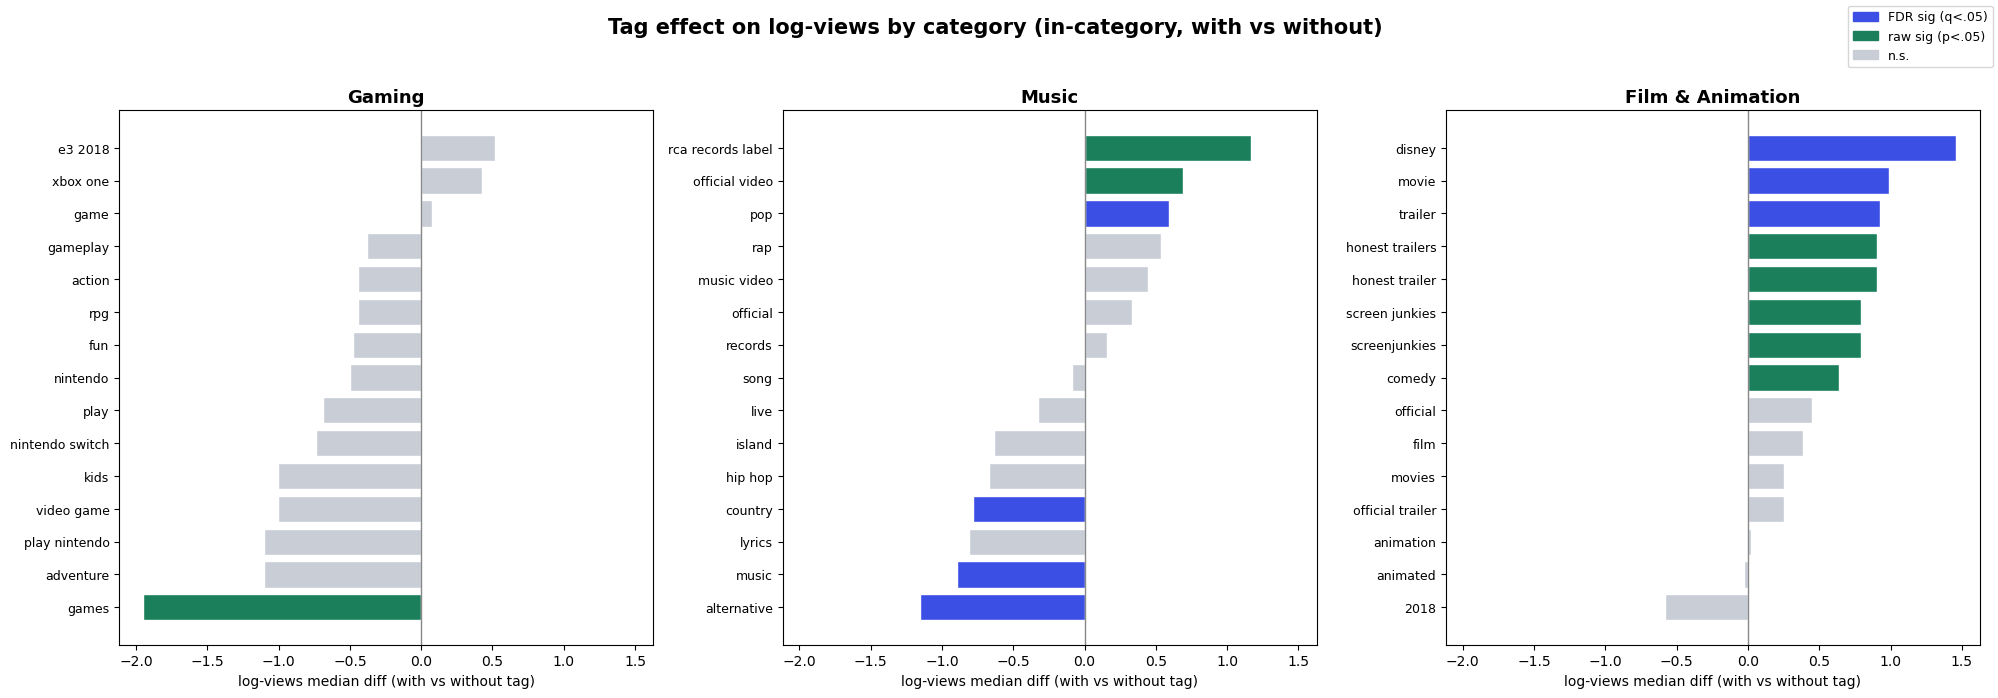

saved: step4_fig_tag_effects.png


In [2]:
res = pd.read_csv('step3_tag_effect_top3.csv')
TARGET = ['Gaming', 'Music', 'Film & Animation']
PRIMARY, ACCENT, GRAY = '#3B4FE4', '#1A7F5A', '#C8CDD6'
plt.rcParams['font.family'] = 'DejaVu Sans'

def bar_color(r):
    if r['sig_fdr'] == '*':
        return PRIMARY
    if r['sig'] == '*':
        return ACCENT
    return GRAY

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True)
for ax, cat in zip(axes, TARGET):
    s = res[res['category'] == cat].sort_values('diff')
    colors = [bar_color(r) for _, r in s.iterrows()]
    ax.barh(s['tag'], s['diff'], color=colors, edgecolor='white')
    ax.axvline(0, color='#888888', linewidth=1)
    ax.set_title(cat, fontsize=13, fontweight='bold')
    ax.set_xlabel('log-views median diff (with vs without tag)', fontsize=10)
    ax.tick_params(axis='y', labelsize=9)

handles = [mpatches.Patch(color=PRIMARY, label='FDR sig (q<.05)'),
           mpatches.Patch(color=ACCENT, label='raw sig (p<.05)'),
           mpatches.Patch(color=GRAY, label='n.s.')]
fig.legend(handles=handles, loc='upper right', fontsize=9)
fig.suptitle('Tag effect on log-views by category (in-category, with vs without)', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('step4_fig_tag_effects.png', dpi=200, bbox_inches='tight')
plt.show()
print('saved: step4_fig_tag_effects.png')

In [3]:
# 발표 요약: 카테고리별 흥행/역효과 태그 (raw 유의 위주)
for cat in TARGET:
    s = res[res['category'] == cat]
    sig = s[s['sig'] == '*']
    pos = sig[sig['diff'] > 0].sort_values('diff', ascending=False).head(3)
    neg = sig[sig['diff'] < 0].sort_values('diff').head(3)
    print('===', cat, '===')
    print('  흥행(+):', list(pos['tag']) if len(pos) else '(유의 없음)')
    print('  역효과(-):', list(neg['tag']) if len(neg) else '(유의 없음)')
print()

print('FDR 생존 태그:')
fdr = res[res['sig_fdr'] == '*'][['category', 'tag', 'diff', 'q']].sort_values(['category', 'diff'], ascending=[True, False])
print(fdr.to_string(index=False) if len(fdr) else '(없음)')

=== Gaming ===
  흥행(+): (유의 없음)
  역효과(-): ['games']
=== Music ===
  흥행(+): ['rca records label', 'official video', 'pop']
  역효과(-): ['alternative', 'music', 'country']
=== Film & Animation ===
  흥행(+): ['disney', 'movie', 'trailer']
  역효과(-): (유의 없음)

FDR 생존 태그:
        category         tag    diff      q
Film & Animation      disney  1.4568 0.0027
Film & Animation       movie  0.9871 0.0179
Film & Animation     trailer  0.9280 0.0041
           Music         pop  0.5908 0.0415
           Music     country -0.7849 0.0115
           Music       music -0.8952 0.0017
           Music alternative -1.1573 0.0177
